<div style="text-align: center">
<img src="./images/logo.png" width="500"/>
</div>

This project focuses on developing a machine learning model for predicting the yield of agricultural crops using Python. 
The model will leverage multiple features, including region, soil type, crop type, temperature, rain fall (mm), fertilization, irrigation, days to harvest, and yield per hectare. By utilizing advanced ML algorithms, the system aims to provide accurate yield forecasts, assisting farmers and agronomists in optimizing agricultural planning and resource allocation. The project will explore various regression models and feature engineering techniques to enhance prediction accuracy and adaptability to different environments.

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:white;
              text-align:center;">
                            Imports and (preparar data?)
              
</p>
</div>

In [ ]:

# Load the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score


In [3]:

# Load the data
data = pd.read_csv('crop_yield.csv')
data = data[data['Yield_tons_per_hectare'] >= 0]	#Ignore cases where the yield is less than 0 (impossible)
data.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [4]:
print(f"This dataframe has {data.shape[0]} rows and {data.shape[1]} columns.\n")
data.info()

This dataframe has 999769 rows and 10 columns.

<class 'pandas.core.frame.DataFrame'>
Index: 999769 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  999769 non-null  object 
 1   Soil_Type               999769 non-null  object 
 2   Crop                    999769 non-null  object 
 3   Rainfall_mm             999769 non-null  float64
 4   Temperature_Celsius     999769 non-null  float64
 5   Fertilizer_Used         999769 non-null  bool   
 6   Irrigation_Used         999769 non-null  bool   
 7   Weather_Condition       999769 non-null  object 
 8   Days_to_Harvest         999769 non-null  int64  
 9   Yield_tons_per_hectare  999769 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 70.6+ MB


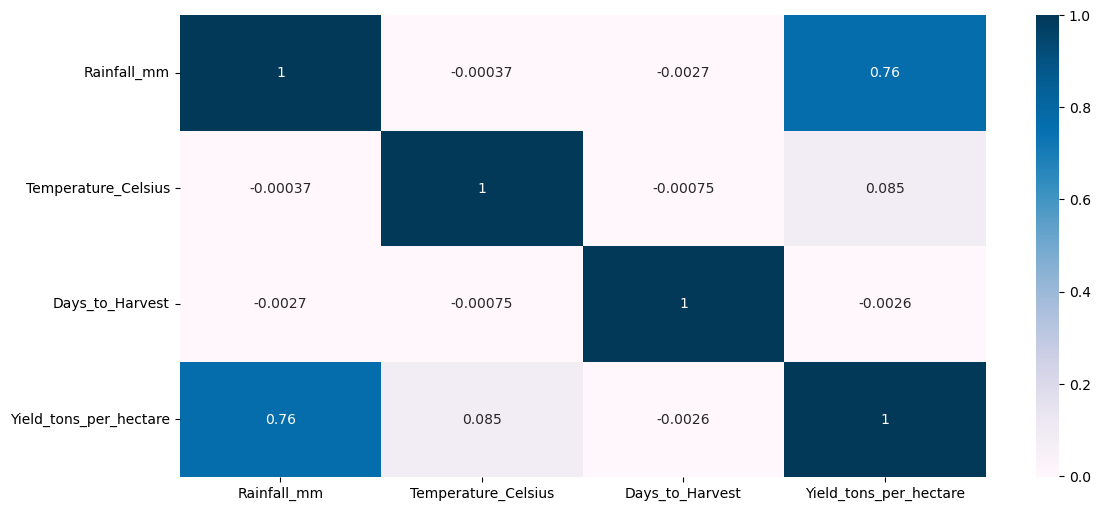

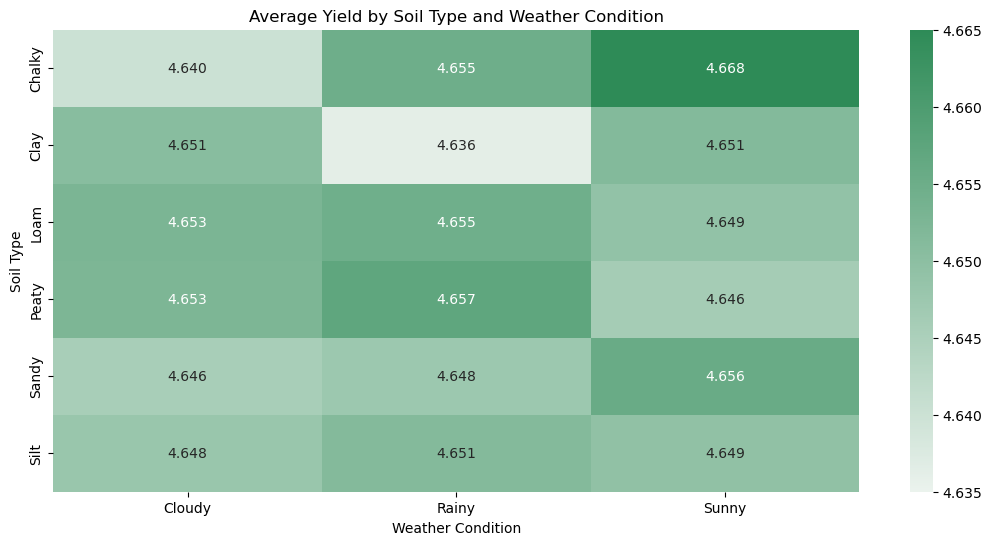

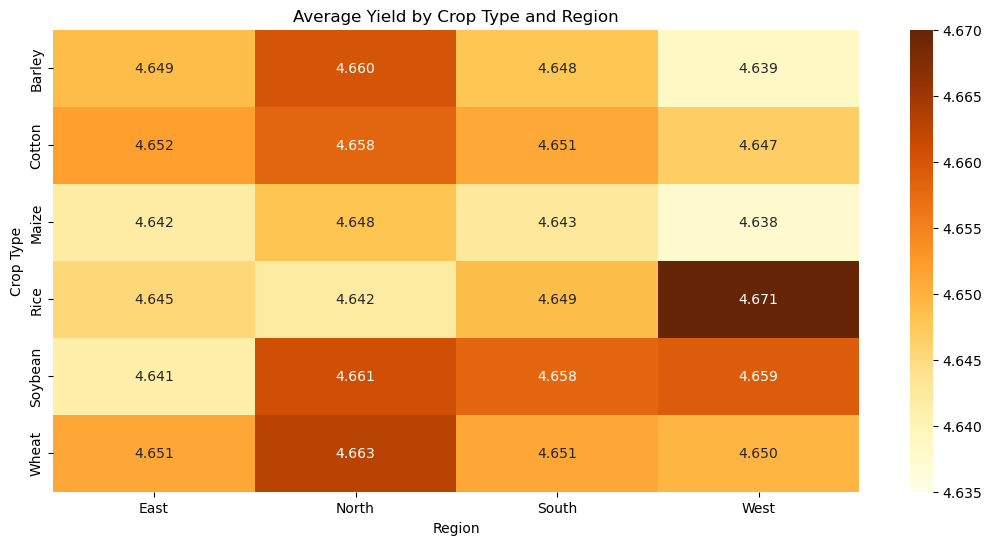

In [5]:
# Test the correlation between the variables, and plot the heatmap
# For the heatmap, we will only consider the numerical variables
data_numeric = data.select_dtypes(include=[np.number])

plt.figure(figsize=(13,6))
sns.heatmap(data_numeric.corr(), annot=True, cmap='PuBu')


#Average Yield by Soil Type and Weather Condition
soil_table = data.pivot_table(
    values='Yield_tons_per_hectare', 
    index='Soil_Type', 
    columns='Weather_Condition', 
)

plt.figure(figsize=(13,6))
mypalette=sns.light_palette("seagreen", as_cmap=True)
sns.heatmap(soil_table, annot=True, fmt=".3f", cmap=mypalette, vmin=4.635, vmax=4.665)

plt.title("Average Yield by Soil Type and Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Soil Type");

#Average Yield by Crop and Region
soil_table = data.pivot_table(
    values='Yield_tons_per_hectare', 
    index='Crop', 
    columns='Region', 
)

plt.figure(figsize=(13,6))
mypalette=sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(soil_table, annot=True, fmt=".3f", cmap=mypalette, vmin=4.635, vmax=4.67)

plt.title("Average Yield by Crop Type and Region")
plt.xlabel("Region")
plt.ylabel("Crop Type");

In [6]:
# This dataframe has 4 column with the thypes of object: Region,Soil Type, crop, Weather Condition
# We need to convert them to numerical values
# We will use the get_dummies method from pandas to convert these columns to numerical values
data_final = pd.get_dummies(data, columns=['Region', 'Soil_Type', 'Crop', 'Weather_Condition'], drop_first=True)

#  Convert the boolean columns to integer and describe the data
for col in data_final.columns:
    if data_final[col].dtype == 'bool':
        data_final[col] = data_final[col].astype(int)
data_final.describe()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region_North,Region_South,Region_West,Soil_Type_Clay,...,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Rainy,Weather_Condition_Sunny
count,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,...,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000
mean,550.077823,27.506079,0.500056,0.499606,104.495141,4.650592,0.250170,0.250059,0.250072,0.166349,...,0.166290,0.167120,0.166672,0.166586,0.166824,0.166793,0.166353,0.166679,0.333568,0.333778
std,259.804329,7.220488,0.500000,0.500000,25.953328,1.695166,0.433111,0.433047,0.433054,0.372394,...,0.372341,0.373083,0.372683,0.372606,0.372818,0.372791,0.372398,0.372689,0.471488,0.471562
min,100.000896,15.000034,0.000000,0.000000,60.000000,0.000411,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,325.062906,21.256078,0.000000,0.000000,82.000000,3.418669,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550.229205,27.509509,1.000000,0.000000,104.000000,4.652333,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,774.797949,33.754459,1.000000,1.000000,127.000000,5.879576,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,999.998098,39.999997,1.000000,1.000000,149.000000,9.963372,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Data Analysis
              
</p>
</div>

<Axes: ylabel='Yield_tons_per_hectare'>

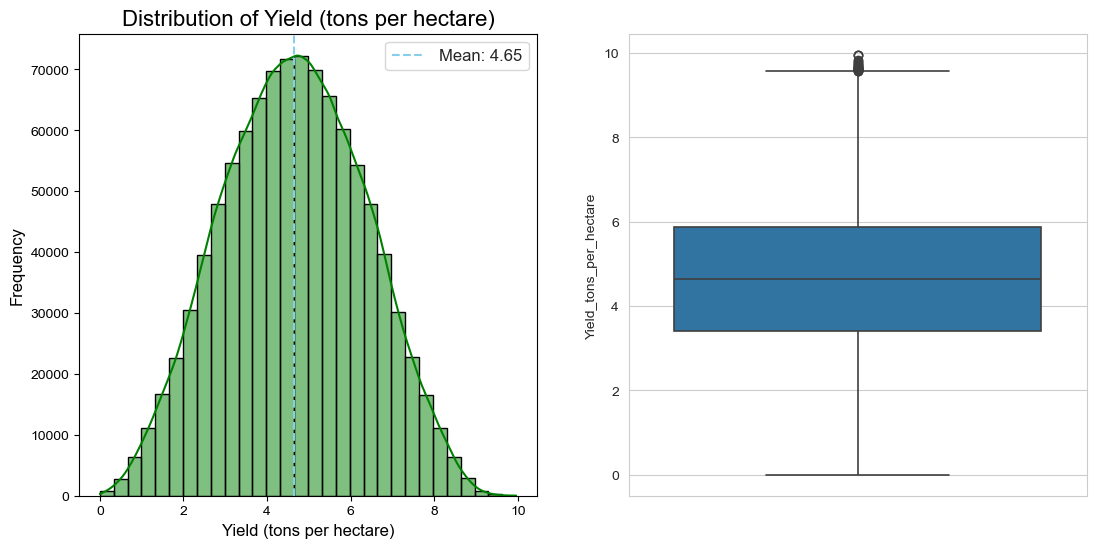

In [7]:

plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Yield_tons_per_hectare'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Yield_tons_per_hectare'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Yield_tons_per_hectare'].mean():.2f}")

plt.title("Distribution of Yield (tons per hectare)", fontsize=16)
plt.xlabel("Yield (tons per hectare)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Yield_tons_per_hectare'], palette=None, linewidth=1.2)


<Axes: ylabel='Rainfall_mm'>

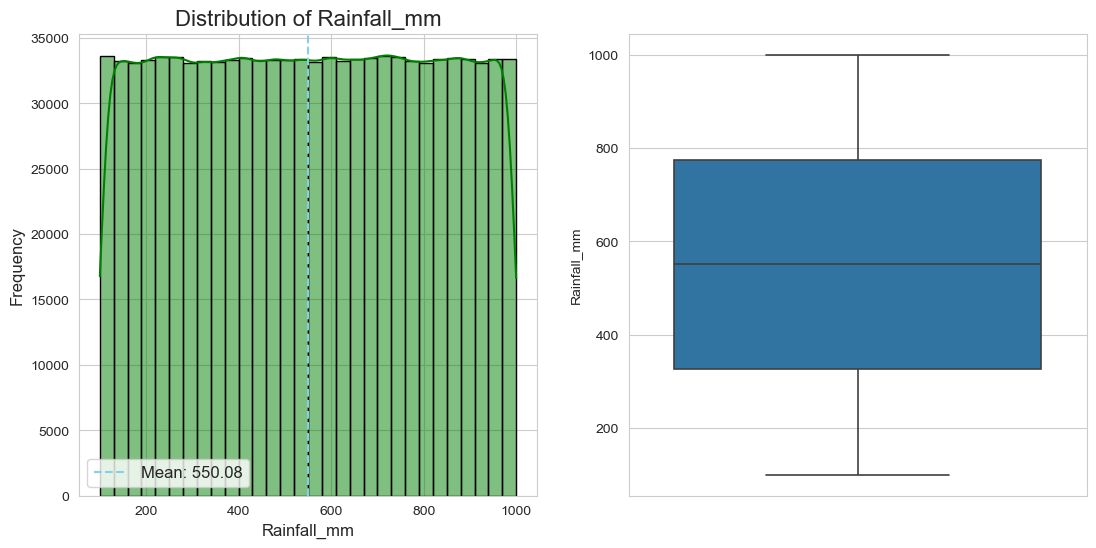

In [8]:

plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Rainfall_mm'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Rainfall_mm'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Rainfall_mm'].mean():.2f}")

plt.title("Distribution of Rainfall_mm", fontsize=16)
plt.xlabel("Rainfall_mm", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Rainfall_mm'], palette=None, linewidth=1.2)

<Axes: ylabel='Temperature_Celsius'>

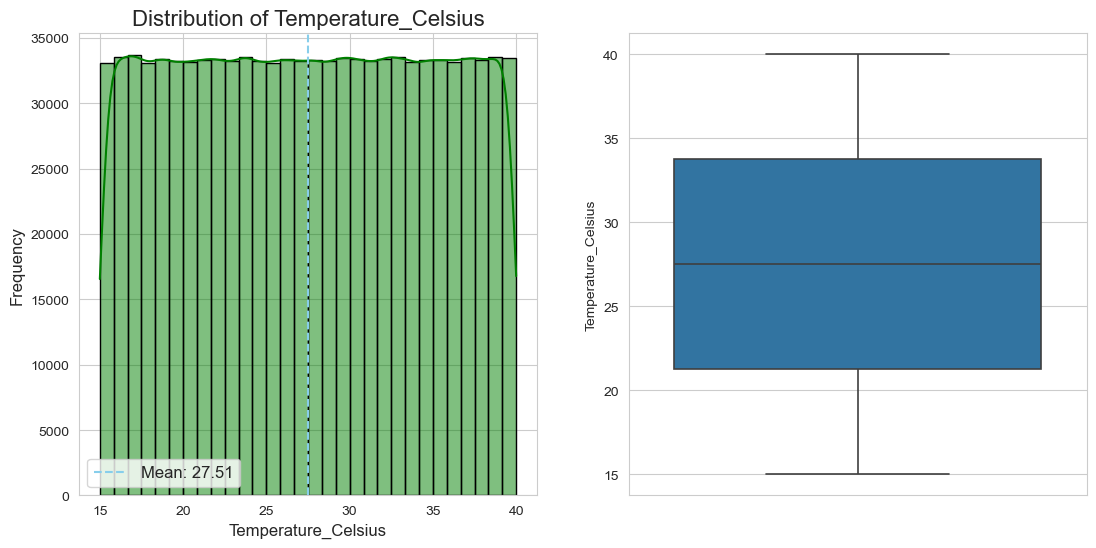

In [9]:

plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Temperature_Celsius'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Temperature_Celsius'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Temperature_Celsius'].mean():.2f}")

plt.title("Distribution of Temperature_Celsius", fontsize=16)
plt.xlabel("Temperature_Celsius", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Temperature_Celsius'], palette=None, linewidth=1.2)

<Axes: ylabel='Fertilizer_Used'>

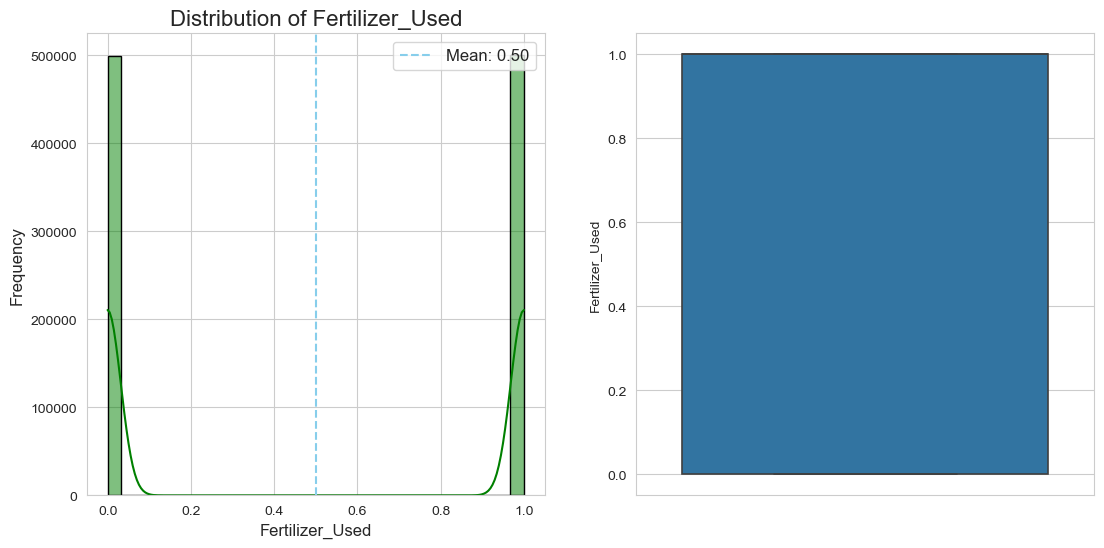

In [10]:
plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Fertilizer_Used'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Fertilizer_Used'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Fertilizer_Used'].mean():.2f}")

plt.title("Distribution of Fertilizer_Used", fontsize=16)
plt.xlabel("Fertilizer_Used", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Fertilizer_Used'], palette=None, linewidth=1.2)

<Axes: ylabel='Irrigation_Used'>

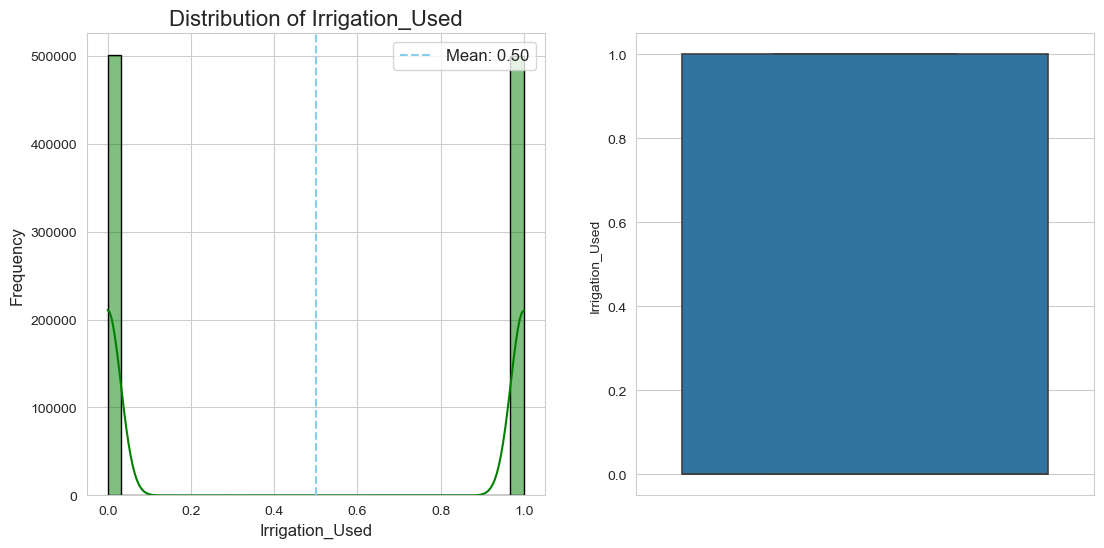

In [11]:
plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Irrigation_Used'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Irrigation_Used'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Irrigation_Used'].mean():.2f}")

plt.title("Distribution of Irrigation_Used", fontsize=16)
plt.xlabel("Irrigation_Used", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Irrigation_Used'], palette=None, linewidth=1.2)

<Axes: ylabel='Days_to_Harvest'>

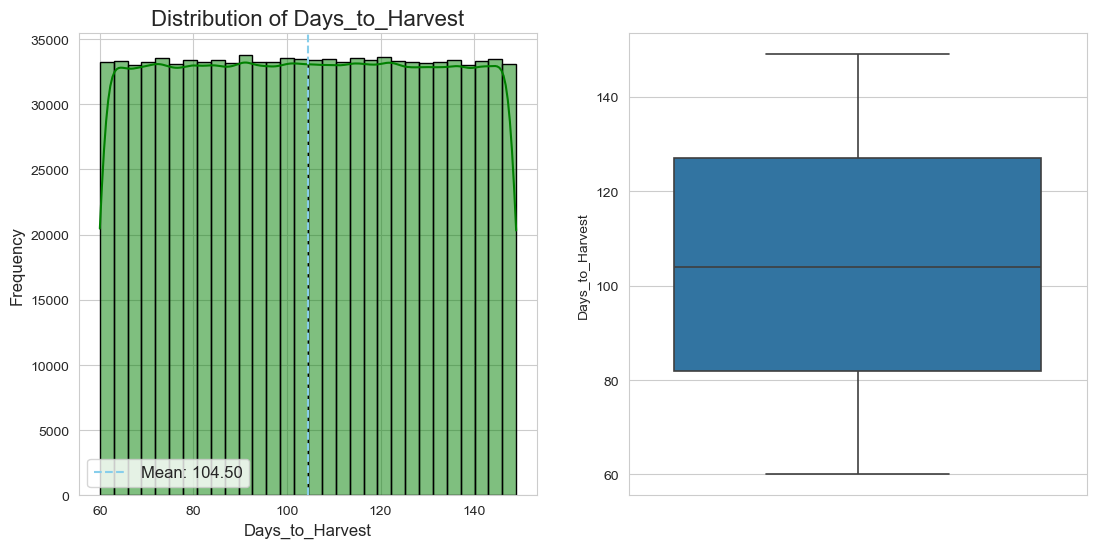

In [12]:
plt.figure(figsize=(13, 6))
plt.subplot(1,2,1)
#Histogram
sns.set_style("whitegrid")

sns.histplot(data['Days_to_Harvest'], bins=30, kde=True, color="green", edgecolor="black")
plt.axvline(data['Days_to_Harvest'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Days_to_Harvest'].mean():.2f}")

plt.title("Distribution of Days_to_Harvest", fontsize=16)
plt.xlabel("Days_to_Harvest", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);
#Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=None,y=data['Days_to_Harvest'], palette=None, linewidth=1.2)

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Data Scaling & Encoding
              
</p>
</div>

In [13]:
from sklearn.preprocessing import normalize


cols_to_scale = ['Rainfall_mm','Temperature_Celsius','Days_to_Harvest']

#create and fit scaler
scaler = StandardScaler()
scaler.fit(data_final[cols_to_scale])

#scale selected data
data_final[cols_to_scale] = scaler.transform(data_final[cols_to_scale])


In [14]:
# Now that we have converted the categorical columns to numerical values, we can split the data into features and target variables
X_train, X_test, y_train, y_test = train_test_split(data_final.drop('Yield_tons_per_hectare', axis=1), data_final['Yield_tons_per_hectare'], test_size=0.2, random_state=42)

In [15]:
def print_evaluate(true,predicted):
    mae = metrics.mean_absolute_error(true,predicted)
    mse = metrics.mean_squared_error(true,predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true,predicted))
    r2_square = metrics.r2_score(true,predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')
    
def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square
    

In [ ]:
lin = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cscore= cross_val_score(lin, X_train, y_train, cv=kf, scoring='r2')
print("Cross Validation Score: ", cscore)
print("Cross Validation Score: ", cscore.mean())
lin.fit(X_train,y_train)

pred = lin.predict(X_test)

print_evaluate(y_test,pred)

Cross Validation Score:  [0.91311264 0.9133231  0.91261939 0.91280262 0.91258156]
Cross Validation Score:  0.9128878628827085
MAE: 0.39833858085913776
MSE: 0.24927155453115368
RMSE: 0.49927102312386773
R2 Square 0.9132337163868854
__________________________________


In [21]:
alph=[0.01, 0.05, 0.1, 0.5]
for k in alph:
    lasso = Lasso(alpha=k)
    lasso.fit(X_train,y_train)
    pred = lasso.predict(X_test)
    print('Alpha:',k)
    print_evaluate(y_test,pred)


Alpha: 0.01
MAE: 0.3990926063575863
MSE: 0.25016421438524084
RMSE: 0.5001641874277294
R2 Square 0.912922999914581
__________________________________
Alpha: 0.05
MAE: 0.41763303092147647
MSE: 0.27377021953172703
RMSE: 0.5232305605865611
R2 Square 0.9047062367088271
__________________________________
Alpha: 0.1
MAE: 0.47188884022783495
MSE: 0.34832874020744214
RMSE: 0.5901938157990493
R2 Square 0.8787539544161644
__________________________________
Alpha: 0.5
MAE: 0.9782663263762967
MSE: 1.4411495696111296
RMSE: 1.2004788917807467
R2 Square 0.4983655775686615
__________________________________


In [34]:

rf = RandomForestRegressor(n_estimators=350, verbose=100)
rf.fit(X_train,y_train)
pred = rf.predict(X_test)

print_evaluate(y_test,pred)
'''
Time to train the model:42.33min
MAE: 0.4098715536866277
MSE: 0.26384851636376766
RMSE: 0.513661869680598
R2 Square 0.9081597768153807
__________________________________'''

building tree 1 of 350
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    8.5s
building tree 2 of 350
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   16.7s
building tree 3 of 350
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   24.0s
building tree 4 of 350
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   31.2s
building tree 5 of 350
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:   38.8s
building tree 6 of 350
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:   46.3s
building tree 7 of 350
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:   53.6s
building tree 8 of 350
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  1.0min
building tree 9 of 350
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  1.1min
building tree 10 of 350
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  1.3min
building tree 11 of 350
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  1.4min
building tree 12 of 350
[Parallel(n_jobs=1)]: Done  12 tasks      | elapse

'\nTime to train the model:42.33min\nMAE: 0.4098715536866277\nMSE: 0.26384851636376766\nRMSE: 0.513661869680598\nR2 Square 0.9081597768153807\n__________________________________'